<div style="background-color: #2E75B6; padding: 15px; border-radius: 6px;">
    <h1 style="color: white; margin: 0; font-size: 2em;">
        Simulation FEM — Électrodes Coplanaires 3D
    </h1
</div>

<h1 style="color: #2E75B6; font-size: 2.5em; border-bottom: 3px solid #2E75B6; padding-bottom: 8px;">
    I. Présentation du projet
</h1>
 
Ce programme implémente une simulation électrostatique par la méthode des éléments finis (FEM) pour modéliser la distribution du potentiel électrique et du champ électrique dans un matériau isolant équipé d'électrodes coplanaires disposées sur sa face supérieure.

**Contexte et objectifs :** Le programme résout l'équation de Laplace dans un domaine 3D :

div( ε · grad(φ) ) = 0

Cette équation gouverne la distribution du potentiel électrostatique φ dans un milieu diélectrique de permittivité ε. Le domaine modélisé représente un capteur capacitif dont les électrodes coplanaires sont déposées sur la face supérieure d'un pavé isolant.

**Méthode numérique:** La méthode des éléments finis (FEM) P1 (éléments tétraédriques linéaires) est utilisée :

•	Maillage tétraédrique structuré (6 tétraèdres par hexaèdre)

•	Fonctions de forme linéaires (P1) sur chaque tétraèdre

•	Assemblage d'une matrice de rigidité globale creuse

•	Conditions de Dirichlet imposées par substitution directe

•	Résolution du système linéaire creux via scipy.sparse.linalg.spsolve

•	Calcul du champ E = -grad(φ) constant par élément

<h1 style="color: #2E75B6; font-size: 2.5em; border-bottom: 3px solid #2E75B6; padding-bottom: 8px;">
    II. Documentation du programmme
</h1>
 
**1- Structure du Notebook**

 Section | Contenu |
|---|---|
| 1. Imports | Chargement des bibliothèques Python |
| 2. Classe `CoplanarElectrodesFEM` | Maillage tétraédrique, assemblage FEM, résolution |
| 3. Paramètres | Géométrie, résolution, matériau, tensions |
| 4. Résolution & visualisation | Exécution de la simulation, tracé des coupes 2D |
| 5. Profil V(z) | Analyse de la variation du potentiel selon la profondeur |
| 6. Sauvegarde | Export des résultats (`.npz`) |

**2-Procédures d'installation**

**2.1 - Prérequis**

    •	Python 3.8 ou supérieur

    •	pip (gestionnaire de paquets Python)

    •	Jupyter Notebook ou JupyterLab (pour exécuter le .ipynb)

    •	Environnement virtuel recommandé (venv ou conda)

**2.2.1 - Installer un environnement virtuel**

**Linux / macOS**

python3 -m venv venv_fem
source venv_fem/bin/activate

**Windows (PowerShell)**

python -m venv venv_fem
.\venv_fem\Scripts\Activate.ps1

**2.2.2 - Installer les dépendances**

pip install -r requirements.txt

**2.2.3 - Lancer Jupyter**

jupyter notebook Notebook_SP4_config_3D.ipynb

# ou avec JupyterLab
jupyter lab Notebook_SP4_config_3D.ipynb

**2.2.4 - Vérifications de l'installation**

import numpy; print(numpy.__version__)
import scipy; print(scipy.__version__)
import matplotlib; print(matplotlib.__version__)

Si aucune erreur n'est levée, l'environnement est prêt !!

<h1 style="color: #2E75B6; font-size: 2.5em; border-bottom: 3px solid #2E75B6; padding-bottom: 8px;">
    III. Le programme complet
</h1>

**1. Imports et configuration**

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve
from matplotlib.tri import Triangulation
import matplotlib.patches as patches

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


**2. Définition de la classe `CoplanarElectrodesFEM`**

In [65]:
class CoplanarElectrodesFEM:
    """
    FEM pour electrostatique avec electrodes coplanaires sur la face superieure.
    Resout l'equation de Laplace : div(eps grad phi) = 0
    Domaine 3D : x in [0, length], y in [0, height], z in [0, depth]
    """

    def __init__(self, use_electrode2=True, length=1.0, height=0.5, depth=0.3,
                 nx=20, ny=20, nz=15, electrode1_pos=(0.4, 0.6,0.14,0.16),
                 electrode2_pos=(0.7,0.8,0.1,0.2), epsilon_r=4.0):
        self.use_electrode2  = use_electrode2
        self.length          = length
        self.height          = height
        self.depth           = depth
        self.nx              = nx
        self.ny              = ny
        self.nz              = nz
        self.electrode1_pos  = electrode1_pos
        self.electrode2_pos  = electrode2_pos
        self.epsilon_r       = epsilon_r
        self.epsilon_0       = 8.854187817e-12  # F/m
        self.generate_mesh()

    # ------------------------------------------------------------------
    # Maillage
    # ------------------------------------------------------------------

    def generate_mesh(self):
        """Genere un maillage tetraedrique structure 3D (6 tets par hexaedre)."""
        x = np.linspace(0, self.length, self.nx)
        y = np.linspace(0, self.height, self.ny)
        z = np.linspace(0, self.depth,  self.nz)
        X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

        self.nodes   = np.column_stack([X.ravel(), Y.ravel(), Z.ravel()])
        self.n_nodes = len(self.nodes)

        def node_id(i, j, k):
            return i * (self.ny * self.nz) + j * self.nz + k

        tets = []
        for i in range(self.nx - 1):
            for j in range(self.ny - 1):
                for k in range(self.nz - 1):
                    n000 = node_id(i,   j,   k  )
                    n100 = node_id(i+1, j,   k  )
                    n010 = node_id(i,   j+1, k  )
                    n110 = node_id(i+1, j+1, k  )
                    n001 = node_id(i,   j,   k+1)
                    n101 = node_id(i+1, j,   k+1)
                    n011 = node_id(i,   j+1, k+1)
                    n111 = node_id(i+1, j+1, k+1)
                    tets.append([n000, n100, n110, n111])
                    tets.append([n000, n110, n010, n111])
                    tets.append([n000, n010, n011, n111])
                    tets.append([n000, n011, n001, n111])
                    tets.append([n000, n001, n101, n111])
                    tets.append([n000, n101, n100, n111])

        self.elements   = np.array(tets)          # shape (N_elem, 4)
        self.n_elements = len(self.elements)

        # Face superieure y = height
        top_mask = np.abs(self.nodes[:, 1] - self.height) < 1e-10
        top_idx  = np.where(top_mask)[0]

        x1s, x1e, z1s, z1e = self.electrode1_pos[:4]   
        self.electrode1_nodes = top_idx[(self.nodes[top_idx, 0] >= x1s) & (self.nodes[top_idx, 0] <= x1e) & (self.nodes[top_idx, 2] >= z1s) & (self.nodes[top_idx, 2] <= z1e)]

        if self.use_electrode2:
            x2s, x2e, z2s, z2e = self.electrode2_pos

            self.electrode2_nodes = top_idx[
                (self.nodes[top_idx, 0] >= x2s) & (self.nodes[top_idx, 0] <= x2e) &
                (self.nodes[top_idx, 2] >= z2s) & (self.nodes[top_idx, 2] <= z2e)
            ]
        else:
            self.electrode2_nodes = np.array([])

        # Face inferieure y = 0
        self.bottom_nodes = np.where(np.abs(self.nodes[:, 1]) < 1e-10)[0]

        print(f"Maillage 3D  : {self.n_nodes} noeuds, {self.n_elements} tetraedres")
        print(f"Domaine      : {self.length} x {self.height} x {self.depth} m")
        print(f"Grille       : {self.nx} x {self.ny} x {self.nz} noeuds")
        print(f"elements.shape = {self.elements.shape}  (doit etre (N, 4))")
        print(f"Electrode 1  : {len(self.electrode1_nodes)} noeuds "
              f"(x in [{x1s:.2f}, {x1e:.2f}] m)")
        if self.use_electrode2 and self.electrode2_pos is not None:
            print(f"Electrode 2  : {len(self.electrode2_nodes)} noeuds "
                  f"(x in [{x2s:.2f}, {x2e:.2f}] m)")

    # ------------------------------------------------------------------
    # Assemblage FEM
    # ------------------------------------------------------------------

    def local_stiffness_matrix(self, elem_nodes):
        """Matrice de rigidite locale 4x4 pour un tetraedre lineaire P1."""
        # elem_nodes : array (4, 3)
        coords = np.array(elem_nodes)          # (4, 3)
        M = np.hstack([np.ones((4, 1)), coords])  # (4, 4)
        volume = abs(np.linalg.det(M)) / 6.0
        if volume < 1e-20:
            return np.zeros((4, 4))
        M_inv = np.linalg.inv(M)
        grads = M_inv[1:, :].T   # (3, 4) : grads[:, i] = grad N_i
        eps   = self.epsilon_0 * self.epsilon_r
        return eps * volume * (grads @ grads.T)  # (4, 4)

    def assemble_global_matrix(self):
        """Assemble la matrice de rigidite globale (sparse)."""
        K = lil_matrix((self.n_nodes, self.n_nodes))
        for elem in self.elements:              # elem : 4 indices
            K_loc = self.local_stiffness_matrix(self.nodes[elem])  # (4,4)
            for i in range(4):
                for j in range(4):
                    K[elem[i], elem[j]] += K_loc[i, j]
        return K.tocsr()

    # ------------------------------------------------------------------
    # Conditions aux limites & resolution
    # ------------------------------------------------------------------

    def apply_boundary_conditions(self, K, F,
                                   V_electrode1=100.0,
                                   V_electrode2=0.0,
                                   V_bottom=0.0):
        """Conditions de Dirichlet par substitution directe."""
        K_mod = K.tolil()
        F_mod = F.copy()

        def impose(node, val):
            K_mod[node, :] = 0
            K_mod[node, node] = 1
            F_mod[node] = val

        for node in self.electrode1_nodes:
            impose(node, V_electrode1)
        if self.use_electrode2:
            for node in self.electrode2_nodes:
                impose(node, V_electrode2)
        for node in self.bottom_nodes:
            impose(node, V_bottom)

        return K_mod.tocsr(), F_mod

    def solve(self, V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0):
        """Assemble et resout le systeme lineaire."""
        print("Assemblage de la matrice globale...")
        K = self.assemble_global_matrix()
        F = np.zeros(self.n_nodes)
        print("Application des conditions aux limites...")
        K_mod, F_mod = self.apply_boundary_conditions(
            K, F, V_electrode1, V_electrode2, V_bottom)
        print("Resolution du systeme lineaire...")
        self.phi = spsolve(K_mod, F_mod)
        print(f"phi in [{self.phi.min():.3f}, {self.phi.max():.3f}] V")
        return self.phi 
    # ------------------------------------------------------------------
    # Champ electrique
    # ------------------------------------------------------------------

    def compute_electric_field(self):
        """Calcule E = -grad(phi) par element (constante par tetraedre)."""
        E = np.zeros((self.n_elements, 3))
        for k, elem in enumerate(self.elements):
            coords = self.nodes[elem]                        # (4, 3)
            M      = np.hstack([np.ones((4, 1)), coords])   # (4, 4)
            try:
                M_inv = np.linalg.inv(M)
            except np.linalg.LinAlgError:
                continue
            grad_phi = M_inv[1:, :] @ self.phi[elem]        # (3,1)
            E[k]     = -grad_phi
        self.E_field = E
        Emag = np.linalg.norm(E, axis=1)
        print(f"|E| max = {Emag.max():.2f} V/m,  |E| moy = {Emag.mean():.2f} V/m")
        return E

    # ------------------------------------------------------------------
    # Visualisation
    # ------------------------------------------------------------------

    def plot_results(self, V_electrode1=100.0, V_electrode2=0.0,
                     V_bottom=0.0, x_cuts=None, z_cut=None):
        """Figures de resultats via coupes 2D dans le volume 3D."""
        if z_cut is None:
            z_cut = self.depth / 2.0

        z_mesh = np.unique(self.nodes[:, 2])
        z_snap = z_mesh[np.argmin(np.abs(z_mesh - z_cut))]
        tol_z  = self.depth / (2*(self.nz-1))

        cut_mask  = np.abs(self.nodes[:, 2] - z_snap) < tol_z
        cut_idx   = np.where(cut_mask)[0]
        local_id  = {g: l for l, g in enumerate(cut_idx)}
        cut_nodes = self.nodes[cut_idx]
        cut_phi   = self.phi[cut_idx]

        cut_tris = []
        for elem in self.elements:
            in_cut = [n for n in elem if n in local_id]
            if len(in_cut) == 3:
                cut_tris.append([local_id[n] for n in in_cut])
        cut_tris = np.array(cut_tris) if cut_tris else np.zeros((0, 3), dtype=int)
        tri = Triangulation(cut_nodes[:, 0], cut_nodes[:, 1], cut_tris)

        x1s, x1e,z1s, z1e = self.electrode1_pos
        levels = np.linspace(cut_phi.min(), cut_phi.max(), 25)

        # ── Figure 1 : maillage / potentiel / equipotentielles ──────
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        fig.suptitle(f"Coupe z = {z_snap:.3f} m  "
                     f"(domaine {self.length} x {self.height} x {self.depth} m)",
                     fontsize=12, fontweight='bold')
        fig.subplots_adjust(left=0.06, right=0.97, top=0.85,
                            bottom=0.12, wspace=0.45)

        ax1 = axes[0]
        ax1.triplot(tri, 'k-', linewidth=0.2, alpha=0.3)
        ax1.add_patch(patches.Rectangle(
            (x1s, self.height - 0.01), x1e - x1s, 0.02,
            lw=2, edgecolor='red', facecolor='red', alpha=0.7,
            label=f'Electrode 1 ({V_electrode1} V)'))
        if self.use_electrode2 and self.electrode2_pos is not None:
            x2s, x2e, z2s, z2e = self.electrode2_pos
            ax1.add_patch(patches.Rectangle(
                (x2s, self.height - 0.01), x2e - x2s, 0.02,
                lw=2, edgecolor='blue', facecolor='blue', alpha=0.7,
                label=f'Electrode 2 ({V_electrode2} V)'))
        ax1.set(xlabel='x (m)', ylabel='y (m)')
        ax1.set_title('Maillage (coupe z)', fontsize=11, fontweight='bold')
        ax1.set_aspect('equal'); ax1.grid(True, alpha=0.2)
        ax1.legend(fontsize=8, loc='lower left')

        ax2 = axes[1]
        cf2 = ax2.tricontourf(tri, cut_phi, levels=levels, cmap='RdYlBu_r')
        cb2 = plt.colorbar(cf2, ax=ax2, fraction=0.046, pad=0.04)
        cb2.set_label('phi (V)', fontsize=9)
        ax2.set(xlabel='x (m)', ylabel='y (m)')
        ax2.set_title('Potentiel electrique', fontsize=11, fontweight='bold')
        ax2.set_aspect('equal')

        ax3 = axes[2]
        ax3.tricontourf(tri, cut_phi, levels=levels, cmap='RdYlBu_r', alpha=0.6)
        ax3.tricontour(tri, cut_phi, levels=20,
                       colors='black', linewidths=1, alpha=0.8)
        ax3.set(xlabel='x (m)', ylabel='y (m)')
        ax3.set_title('Lignes equipotentielles', fontsize=11, fontweight='bold')
        ax3.set_aspect('equal')

        plt.savefig('coplanar_3d_results.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 1 sauvegardee : coplanar_3d_results.png")

        # ── Figure 2 : profils V(y) et V(x) ────────────────────────
        fig2, (ax_cut, ax_h) = plt.subplots(1, 2, figsize=(14, 5))
        fig2.suptitle(f"Profils de potentiel - coupe z = {z_snap:.3f} m",
                      fontsize=12, fontweight='bold')
        fig2.subplots_adjust(left=0.08, right=0.97, top=0.88,
                             bottom=0.13, wspace=0.35)

        if x_cuts is None:
            x_cuts_used = [round(self.length * f, 3)
                           for f in [0.1, 0.25, 0.5, 0.75, 0.99]]
        else:
            x_cuts_used = x_cuts

        tol_xy     = self.length / (2*(self.nx-1))
        x_mesh_cut = np.unique(cut_nodes[:, 0])
        colors_vy  = plt.cm.tab10(np.linspace(0, 0.9, len(x_cuts_used)))

        for xc, col in zip(x_cuts_used, colors_vy):
            if not (0 <= xc <= self.length):
                raise ValueError(f"x_cuts contient {xc} m hors du domaine.")
            xc_snap = x_mesh_cut[np.argmin(np.abs(x_mesh_cut - xc))]
            mask    = np.abs(cut_nodes[:, 0] - xc_snap) < tol_xy
            y_v, p_v = cut_nodes[mask, 1], cut_phi[mask]
            si = np.argsort(y_v)
            ax_cut.plot(y_v[si], p_v[si], '-o', color=col,
                        lw=2, ms=4, label=f'x = {xc_snap:.3f} m')

        ax_cut.axvline(self.height, ls='--', color='red',   alpha=0.6)
        ax_cut.axvline(0,           ls='--', color='black', alpha=0.6)
        ax_cut.set(xlabel='y (m)', ylabel='phi (V)', xlim=(0, self.height))
        ax_cut.set_title('Profils V(y)', fontsize=11, fontweight='bold')
        ax_cut.legend(fontsize=8); ax_cut.grid(True, alpha=0.3)

        for _, h in [(0.2, 0.2*self.height),
                     (0.5, 0.5*self.height),
                     (0.8, 0.8*self.height)]:
            tol_h = self.height / (2 * (self.ny - 1))
            mask_h = np.abs(cut_nodes[:, 1] - h) < tol_h
            x_h, p_h = cut_nodes[mask_h, 0], cut_phi[mask_h]
            si = np.argsort(x_h)
            ax_h.plot(x_h[si], p_h[si], '-o', lw=2, ms=3,
                      label=f'y = {h:.2f} m')

        ax_h.axvspan(x1s, x1e, alpha=0.2, color='red', label='Electrode 1')
        if self.use_electrode2 and self.electrode2_pos is not None:
            ax_h.axvspan(x2s, x2e, alpha=0.2, color='blue', label='Electrode 2')
        ax_h.set(xlabel='x (m)', ylabel='phi (V)', xlim=(0, self.length))
        ax_h.set_title('Profils V(x)', fontsize=11, fontweight='bold')
        ax_h.legend(fontsize=8); ax_h.grid(True, alpha=0.3)

        plt.savefig('coplanar_3d_profiles.png', dpi=150, bbox_inches='tight')
        plt.show()
        print("Figure 2 sauvegardee : coplanar_3d_profiles.png")

    # ------------------------------------------------------------------
    # Profil V(z) : potentiel le long de z pour differentes positions (x, y)
    # ------------------------------------------------------------------

    def plot_profile_z(self, xy_points=None, x_cut=None, y_cut=None):
        """
        Trace le profil 
        ) le long de l'axe z pour differents points (x, y).

        Parametres
        ----------
        xy_points : list of (x, y) tuples
            Points (x, y) pour lesquels tracer V(z).
            Par defaut : 3 positions representatives.
        x_cut : float, optional
            Si fourni avec y_cut, ajoute ce point unique.
        y_cut : float, optional
            Hauteur y pour le profil (ex: 0.25 = milieu du domaine).
        """
        if xy_points is None:
            xy_points = [
                (self.length * 0.25,  self.height * 0.7),   # proche electrode, haut
                (self.length * 0.75,  self.height * 0.5),   # centre du domaine
                (self.length * 0.5,  self.height * 0.25),   # pres du fond
            ]
        if x_cut is not None and y_cut is not None:
            xy_points = xy_points + [(x_cut, y_cut)]

        z_mesh = np.unique(self.nodes[:, 2])
        x_mesh = np.unique(self.nodes[:, 0])
        y_mesh = np.unique(self.nodes[:, 1])
        tol_x  = self.length / (2 * (self.nx - 1))
        tol_y  = self.height / (2 * (self.ny - 1))

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
        fig.suptitle('Profil V(z) — variation du potentiel selon la profondeur z',
                     fontsize=12, fontweight='bold')
        fig.subplots_adjust(left=0.08, right=0.97, top=0.88,
                            bottom=0.13, wspace=0.35)

        colors = plt.cm.tab10(np.linspace(0, 0.9, len(xy_points)))

        for (xc, yc), col in zip(xy_points, colors):
            # Snap vers le noeud de maillage le plus proche
            xc_snap = x_mesh[np.argmin(np.abs(x_mesh - xc))]
            yc_snap = y_mesh[np.argmin(np.abs(y_mesh - yc))]

            mask = (np.abs(self.nodes[:, 0] - xc_snap) < tol_x) & \
                   (np.abs(self.nodes[:, 1] - yc_snap) < tol_y)

            z_vals  = self.nodes[mask, 2]
            phi_vals = self.phi[mask]
            si = np.argsort(z_vals)
            label = f'x={xc_snap:.2f} m, y={yc_snap:.2f} m'

            ax1.plot(z_vals[si], phi_vals[si], '-o', color=col,
                     lw=2, ms=4, label=label)
            ax2.plot(z_vals[si], phi_vals[si], '-o', color=col,
                     lw=2, ms=4, label=label)

        # Annotations geometriques
        ax1.axvline(0,          ls='--', color='gray',  alpha=0.6, label='z = 0')
        ax1.axvline(self.depth, ls='--', color='gray',  alpha=0.6, label=f'z = {self.depth} m')

        ax1.set(xlabel='z (m)', ylabel='phi (V)',
                xlim=(0, self.depth),
                title='V(z) — echelle lineaire')
        ax1.legend(fontsize=8); ax1.grid(True, alpha=0.3)

        # Axe 2 : variation normalisee pour comparer les formes
        ax2.set(xlabel='z (m)', ylabel='phi (V)',
                xlim=(0, self.depth),
                title='V(z) — zoom sur la variation')
        # Afficher l'ecart max-min dans la legende
        for (xc, yc), col in zip(xy_points, colors):
            xc_snap = x_mesh[np.argmin(np.abs(x_mesh - xc))]
            yc_snap = y_mesh[np.argmin(np.abs(y_mesh - yc))]
            mask = (np.abs(self.nodes[:, 0] - xc_snap) < tol_x) & \
                   (np.abs(self.nodes[:, 1] - yc_snap) < tol_y)
            phi_vals = self.phi[mask]
            delta = phi_vals.max() - phi_vals.min()
            print(f'  x={xc_snap:.2f} m, y={yc_snap:.2f} m : '
                  f'V in [{phi_vals.min():.4f}, {phi_vals.max():.4f}] V  '
                  f'(Delta = {delta:.4f} V)')

        ax2.legend(fontsize=8); ax2.grid(True, alpha=0.3)

        plt.savefig('coplanar_3d_profile_z.png', dpi=150, bbox_inches='tight')
        plt.show()
        print('Figure sauvegardee : coplanar_3d_profile_z.png')
        print()
        print('Interpretation : si V(z) est quasi-constant, le champ est')
        print('essentiellement 2D dans le plan (x,y) — la geometrie est')
        print('suffisamment large en z. Une variation notable indique un')
        print('effet de bord en profondeur.')


**3. Paramètres de simulation**

In [66]:
# ── Geometrie du domaine ────────────────────────────────────────────────────
LENGTH    = 1.0   # longueur (m)
HEIGHT    = 0.5   # hauteur (m)
DEPTH     = 0.3   # epaisseur (m)

# ── Resolution du maillage ──────────────────────────────────────────────────
NX = 60           # noeuds en x  (augmenter = plus precis, plus lent)
NY = 40           # noeuds en y
NZ = 20           # noeuds en z

# ── Materiau ────────────────────────────────────────────────────────────────
EPSILON_R = 4.0   # permittivite relative de l'isolant

# ── Electrodes ──────────────────────────────────────────────────────────────
ELECTRODE1_POS = (0.2, 0.3,0.1,0.2)   # (x_start, x_end,zstart,Zend) en metres
ELECTRODE2_POS = (0.7,0.8,0.1,0.2)       # ex. (0.7, 0.9) pour activer
USE_ELECTRODE2 = True

# ── Tensions (V) ────────────────────────────────────────────────────────────
V_ELECTRODE1 = 4.0
V_ELECTRODE2 = 2.0
V_BOTTOM     = 0.0            # face inferieure (reference)

# ── Visualisation ───────────────────────────────────────────────────────────
Z_CUT  = None    # coupe en z (None = depth/2 automatique)
X_CUTS = None    # ex. [0.2, 0.4, 0.5, 0.6, 0.8]


**4. Initialisation, résolution et visualisation**

Maillage 3D  : 48000 noeuds, 262314 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 60 x 40 x 20 noeuds
elements.shape = (262314, 4)  (doit etre (N, 4))
Electrode 1  : 36 noeuds (x in [0.20, 0.30] m)
Electrode 2  : 36 noeuds (x in [0.70, 0.80] m)
Assemblage de la matrice globale...
Application des conditions aux limites...
Resolution du systeme lineaire...
phi in [0.000, 4.000] V
|E| max = 107.17 V/m,  |E| moy = 3.45 V/m


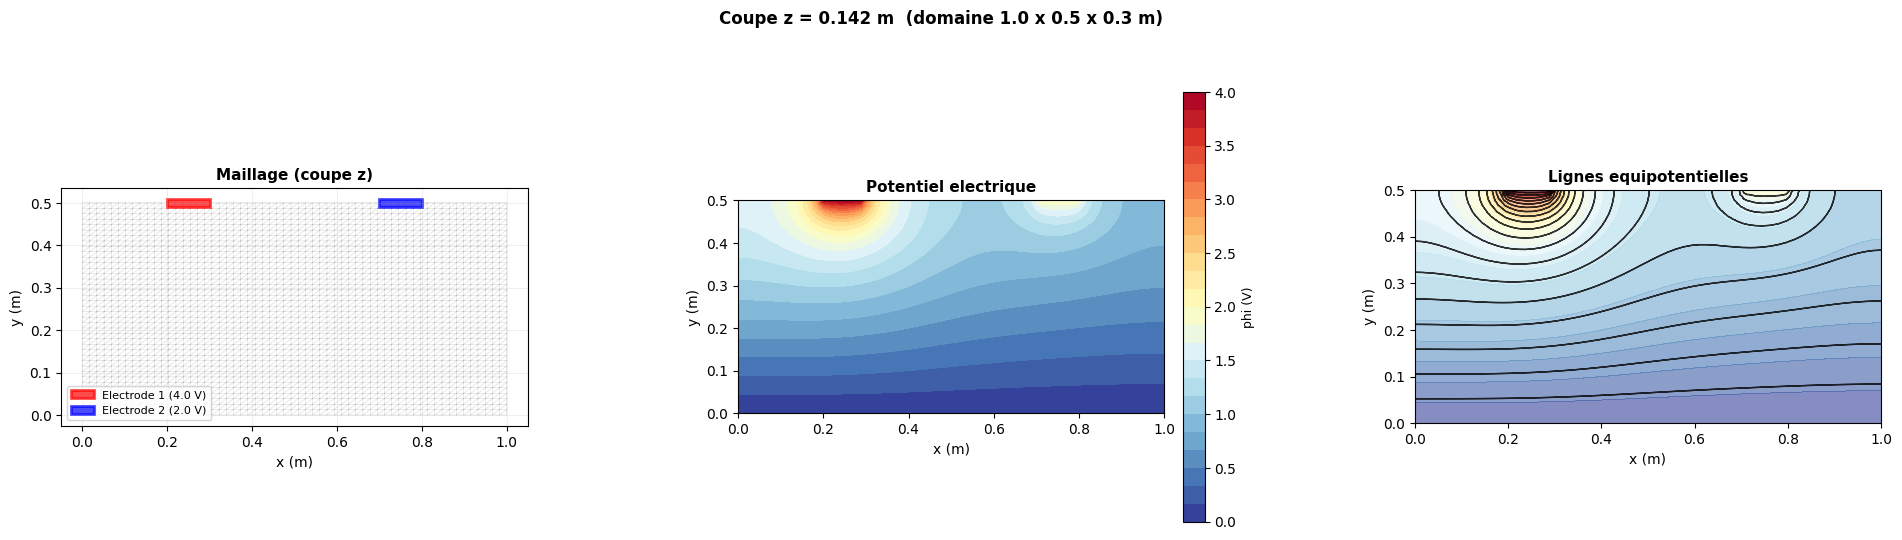

Figure 1 sauvegardee : coplanar_3d_results.png


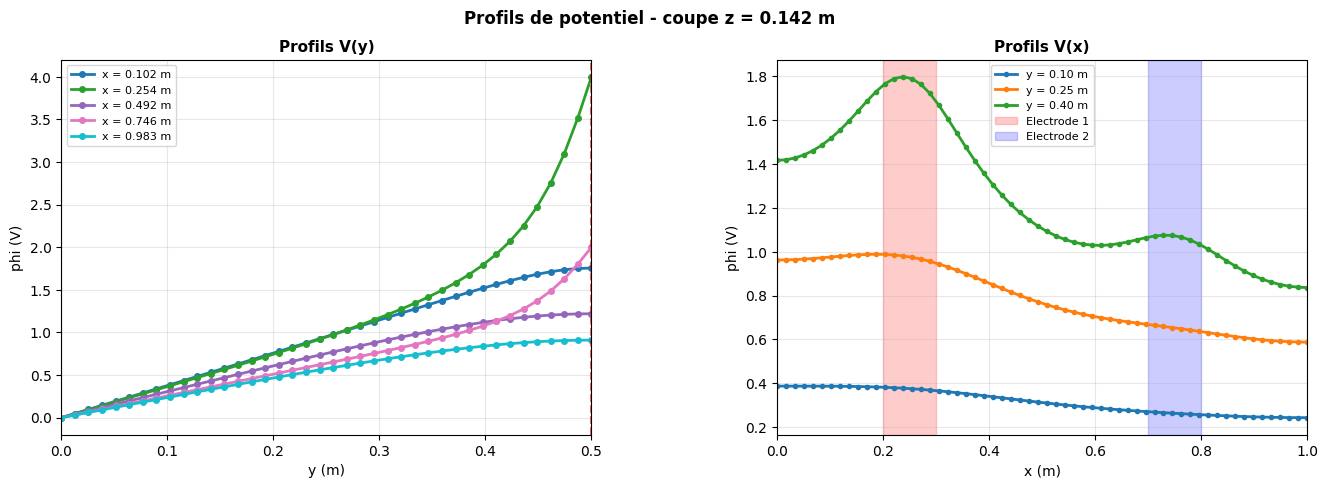

Figure 2 sauvegardee : coplanar_3d_profiles.png


In [67]:
fem = CoplanarElectrodesFEM(
    use_electrode2 = USE_ELECTRODE2,
    length         = LENGTH,
    height         = HEIGHT,
    depth          = DEPTH,
    nx             = NX,
    ny             = NY,
    nz             = NZ,
    electrode1_pos = ELECTRODE1_POS,
    electrode2_pos = ELECTRODE2_POS,
    epsilon_r      = EPSILON_R,
)

phi = fem.solve(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM)
E   = fem.compute_electric_field()
fem.plot_results(V_ELECTRODE1, V_ELECTRODE2, V_BOTTOM,
                 x_cuts=X_CUTS,
                 z_cut=Z_CUT)


**5. Profil du potentiel selon z**

  x=0.49 m, y=0.50 m : V in [1.2064, 1.2193] V  (Delta = 0.0129 V)
  x=0.25 m, y=0.37 m : V in [1.4787, 1.5824] V  (Delta = 0.1036 V)
  x=0.20 m, y=0.10 m : V in [0.3811, 0.3813] V  (Delta = 0.0002 V)
  x=0.25 m, y=0.47 m : V in [1.8913, 3.0990] V  (Delta = 1.2077 V)


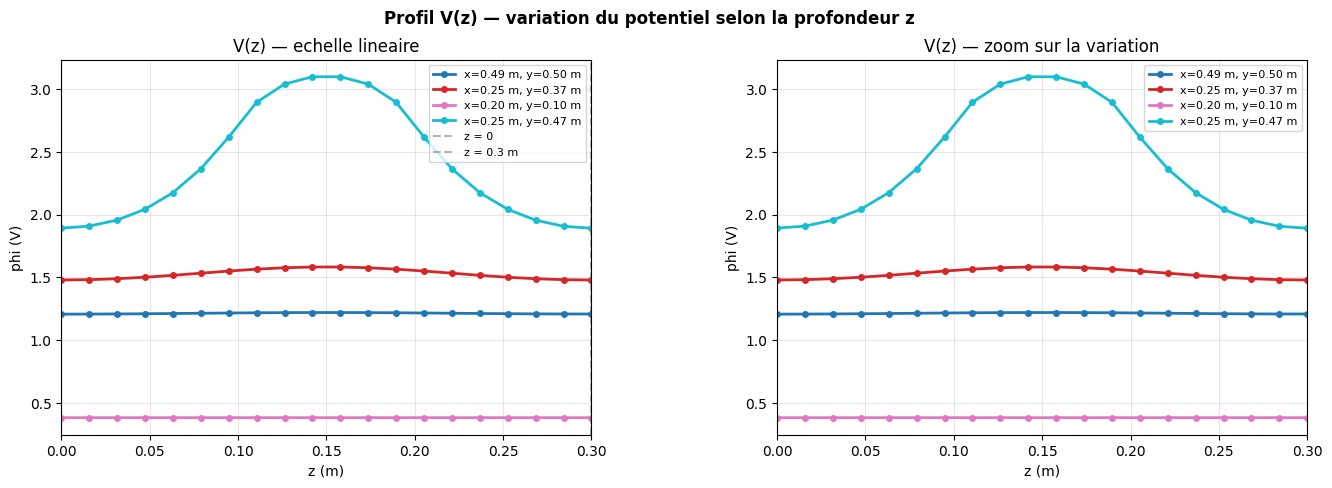

Figure sauvegardee : coplanar_3d_profile_z.png

Interpretation : si V(z) est quasi-constant, le champ est
essentiellement 2D dans le plan (x,y) — la geometrie est
suffisamment large en z. Une variation notable indique un
effet de bord en profondeur.


In [68]:
# ── Profil V(z) : potentiel selon la profondeur z ──────────────────────────
# Differents points (x, y) sont sonderondes le long de z pour observer
# si le potentiel varie selon la troisieme dimension.
#
# Points par defaut :
#   - proche electrode, en haut
#   - centre du domaine
#   - pres du fond
#
# Vous pouvez personnaliser les points (x, y) a sonder :
XY_POINTS = [
    (LENGTH * 0.5,  HEIGHT * 1),   
    (LENGTH * 0.25,  HEIGHT * 0.75),   
    (LENGTH * 0.2,  HEIGHT * 0.2),   
    (ELECTRODE1_POS[0] + (ELECTRODE1_POS[1]-ELECTRODE1_POS[0])/2, HEIGHT * 0.95),  # milieu electrode
]

fem.plot_profile_z(xy_points=XY_POINTS)


**6. Sauvegarde des données**

In [69]:
np.savez(
    'coplanar_data.npz',
    nodes            = fem.nodes,
    elements         = fem.elements,
    phi              = phi,
    E_field          = E,
    electrode1_nodes = fem.electrode1_nodes,
    electrode2_nodes = fem.electrode2_nodes,
    parameters       = {
        'length'         : LENGTH,
        'height'         : HEIGHT,
        'depth'          : DEPTH,
        'electrode1_pos' : ELECTRODE1_POS,
        'electrode2_pos' : ELECTRODE2_POS,
        'epsilon_r'      : EPSILON_R,
        'V_electrode1'   : V_ELECTRODE1,
        'V_electrode2'   : V_ELECTRODE2,
        'V_bottom'       : V_BOTTOM,
    },
)
print("Donnees sauvegardees : coplanar_data.npz")

Donnees sauvegardees : coplanar_data.npz


<h1 style="color: #2E75B6; font-size: 2.5em; border-bottom: 3px solid #2E75B6; padding-bottom: 8px;">
    IV. Exemples d'utilisation
</h1>

**3.1 Simulation de base (deux électrodes)**

Maillage 3D  : 18000 noeuds, 95004 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 40 x 30 x 15 noeuds
elements.shape = (95004, 4)  (doit etre (N, 4))
Electrode 1  : 20 noeuds (x in [0.20, 0.30] m)
Electrode 2  : 20 noeuds (x in [0.70, 0.80] m)
Assemblage de la matrice globale...
Application des conditions aux limites...
Resolution du systeme lineaire...
phi in [0.000, 100.000] V
|E| max = 2194.18 V/m,  |E| moy = 69.97 V/m


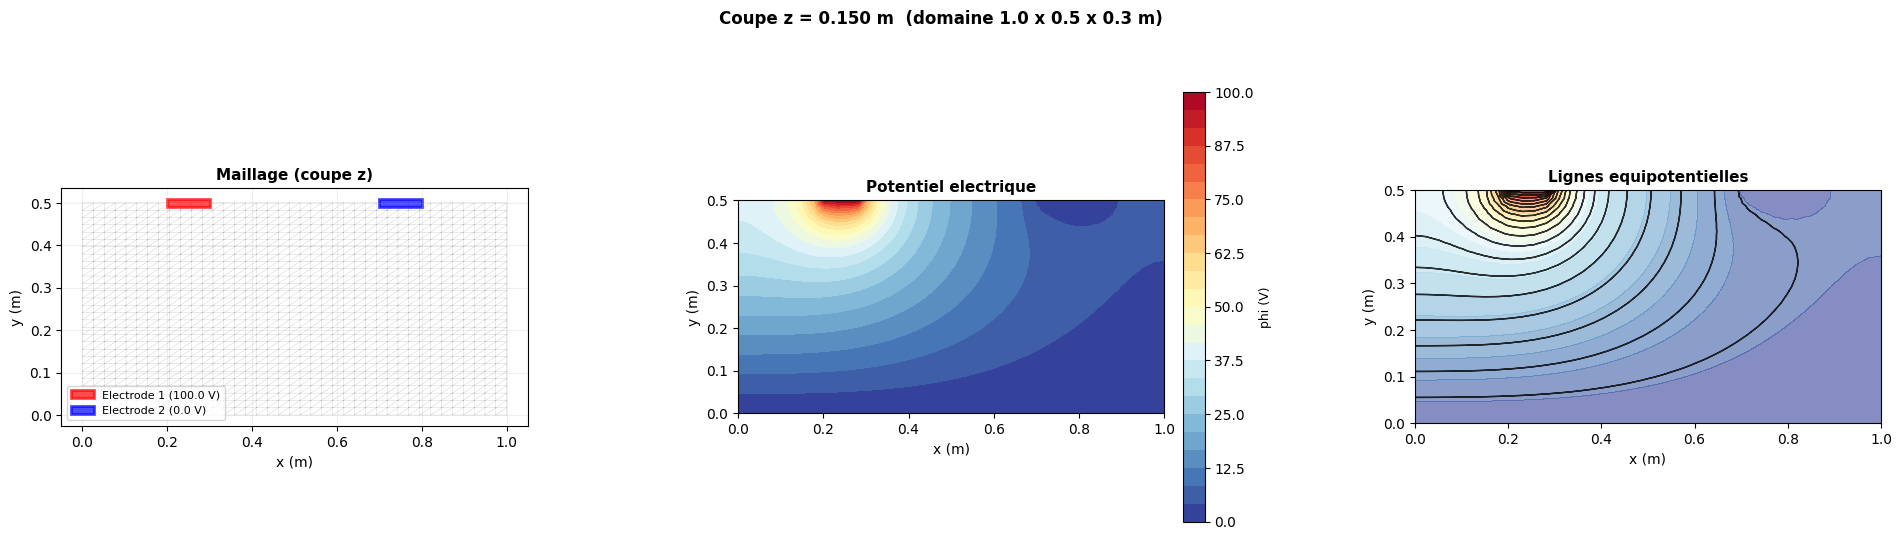

Figure 1 sauvegardee : coplanar_3d_results.png


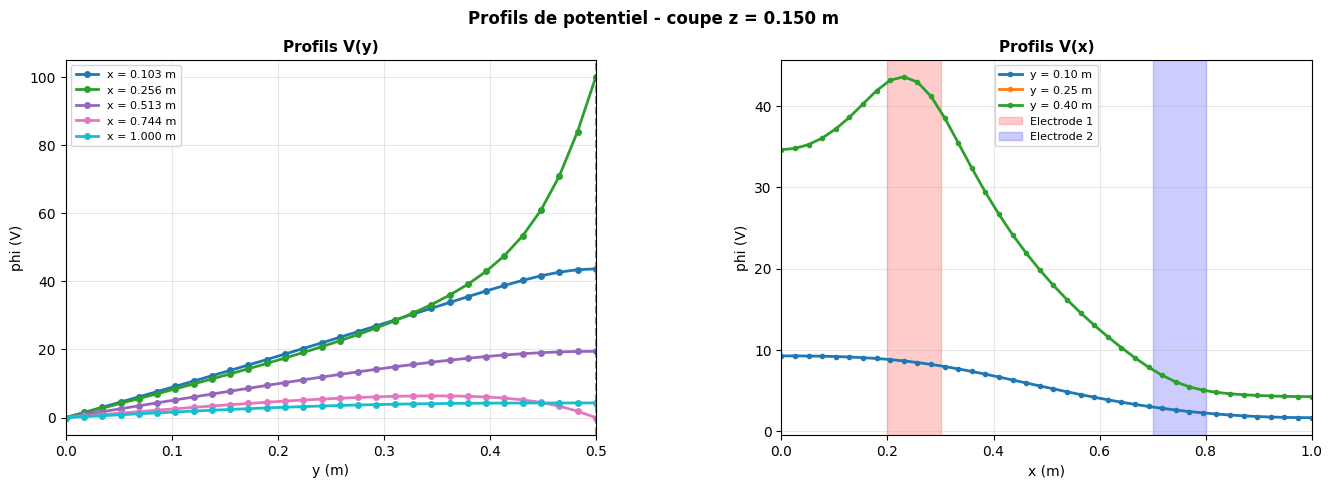

Figure 2 sauvegardee : coplanar_3d_profiles.png


In [70]:
fem = CoplanarElectrodesFEM(
    use_electrode2=True,
    length=1.0, height=0.5, depth=0.3,
    nx=40, ny=30, nz=15,
    electrode1_pos=(0.2, 0.3, 0.1, 0.2),
    electrode2_pos=(0.7, 0.8, 0.1, 0.2),
    epsilon_r=4.0
)

phi = fem.solve(V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0)
E   = fem.compute_electric_field()
fem.plot_results()

**3.2 Simulation avec une seule électrode**

Maillage 3D  : 9000 noeuds, 45936 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 30 x 25 x 12 noeuds
elements.shape = (45936, 4)  (doit etre (N, 4))
Electrode 1  : 24 noeuds (x in [0.40, 0.60] m)
Assemblage de la matrice globale...
Application des conditions aux limites...
Resolution du systeme lineaire...
phi in [0.000, 50.000] V
|E| max = 819.71 V/m,  |E| moy = 50.16 V/m


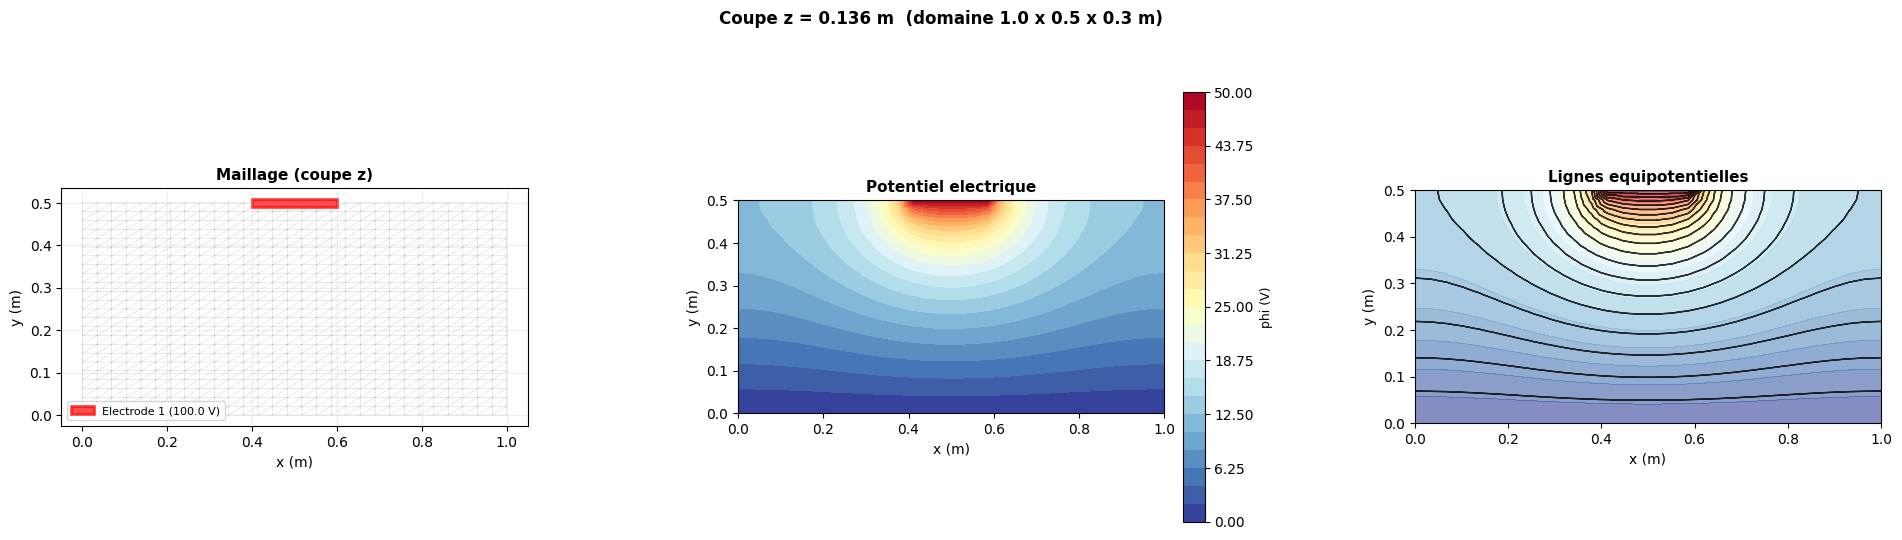

Figure 1 sauvegardee : coplanar_3d_results.png


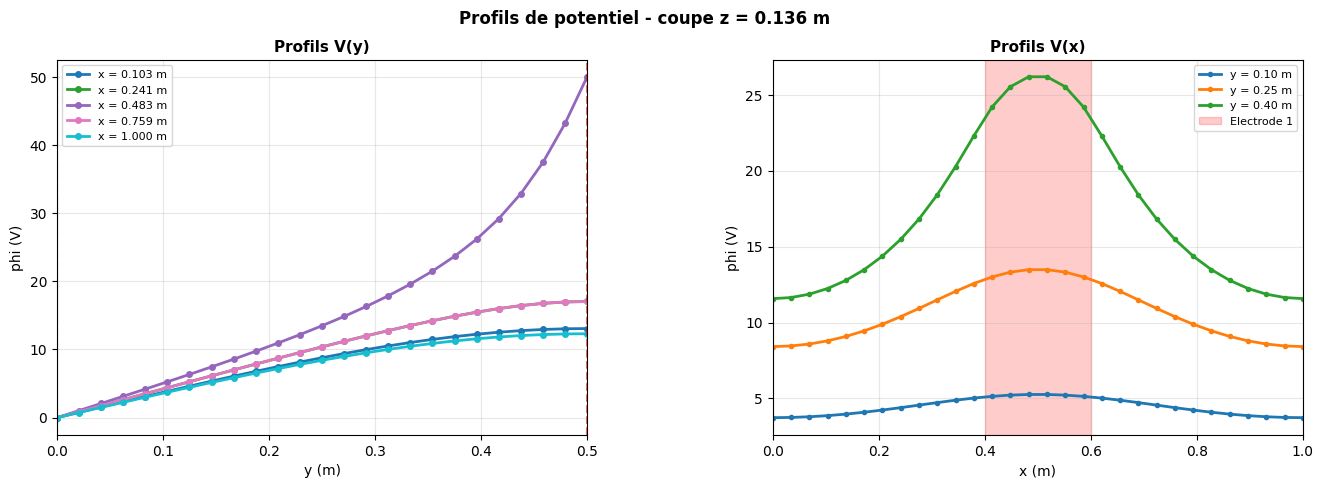

Figure 2 sauvegardee : coplanar_3d_profiles.png


In [71]:
fem_single = CoplanarElectrodesFEM(
    use_electrode2=False,
    length=1.0, height=0.5, depth=0.3,
    nx=30, ny=25, nz=12,
    electrode1_pos=(0.4, 0.6, 0.1, 0.2),
    epsilon_r=2.5  # PTFE par exemple
)

phi = fem_single.solve(V_electrode1=50.0, V_bottom=0.0)
fem_single.compute_electric_field()
fem_single.plot_results()


**3.3 Coupes et visualisation personnalisées**

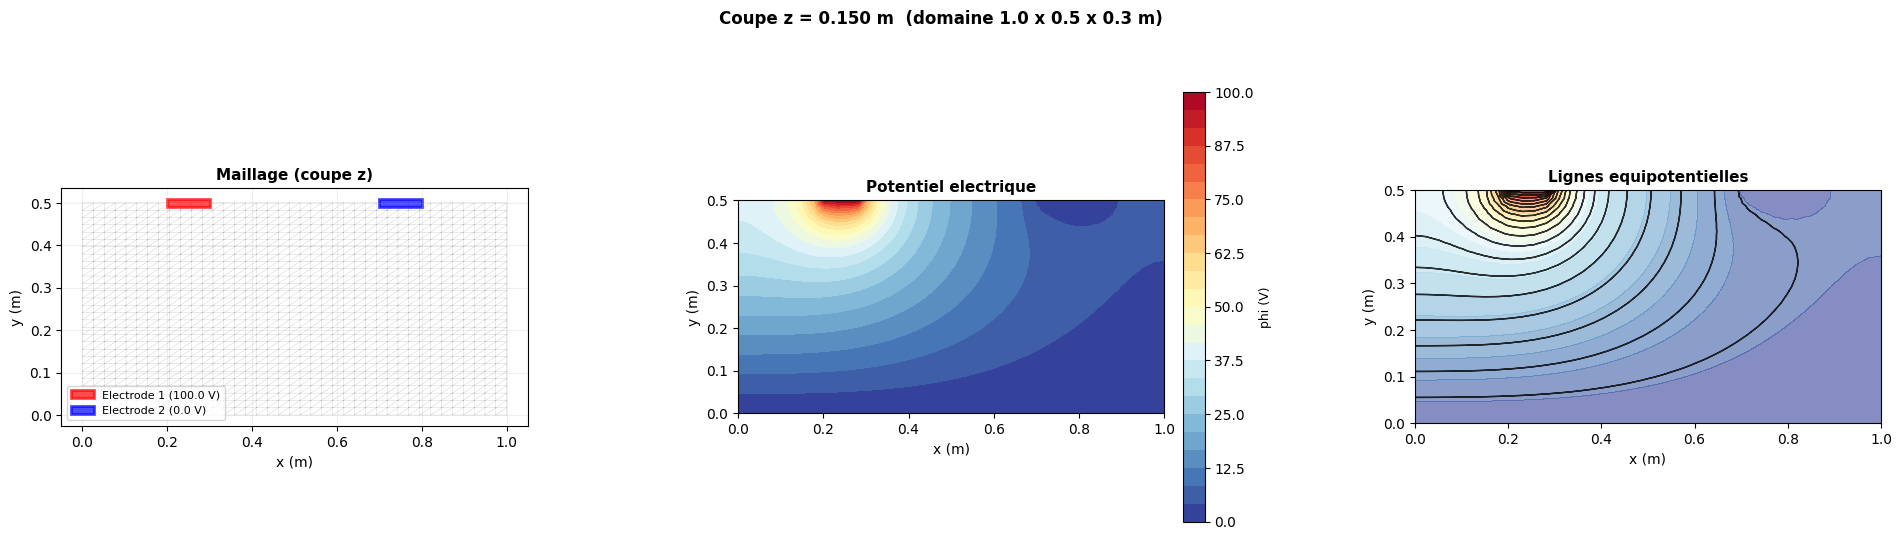

Figure 1 sauvegardee : coplanar_3d_results.png


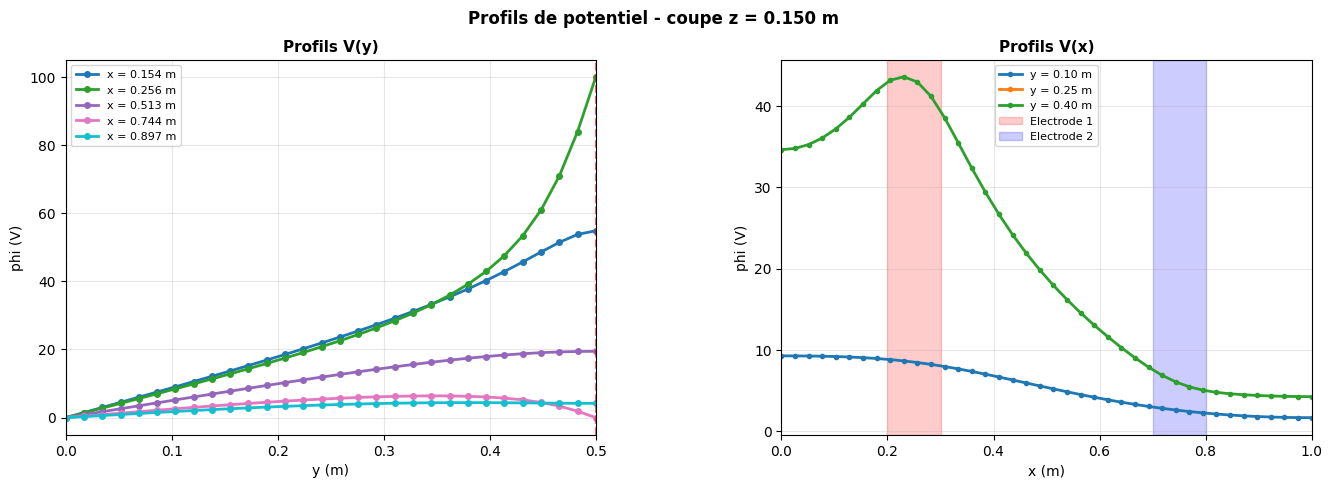

Figure 2 sauvegardee : coplanar_3d_profiles.png


In [72]:
fem.plot_results(
    V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0,
    x_cuts=[0.15, 0.25, 0.50, 0.75, 0.90],
    z_cut=0.15   # coupe à z=0.15 m
)

<h1 style="color: #2E75B6; font-size: 2.5em; border-bottom: 3px solid #2E75B6; padding-bottom: 8px;">
    V. Tests des fonctionnalités — CoplanarElectrodesFEM
</h1>

Cette partie contient l'ensemble des procédures de test pour valider chaque composante du programme de simulation FEM.  
Chaque section teste une fonctionnalité spécifique et affiche un résultat attendu.

**Structure des tests :**
1. Imports et configuration
2. Copie de la classe source
3. Test T1 — Génération du maillage
4. Test T2 — Détection des nœuds d'électrodes
5. Test T3 — Matrice de rigidité locale
6. Test T4 — Assemblage de la matrice globale
7. Test T6 — Résolution du système (solve)
8. Test T7 — Calcul du champ électrique
9. Test T8 — Visualisation plot_results
10. Test T9 — Profil V(z)
11. Test T10 — Sauvegarde et rechargement des données
12. Test T11 — Configuration à une seule électrode
13. Test T12 — Robustesse (paramètres extrêmes)
14. Bilan des tests

In [73]:
# Compteur de résultats
results = {}
def check(name, condition, detail=''):
    status = '✅ PASS' if condition else '❌ FAIL'
    results[name] = condition
    print(f"{status}  [{name}]  {detail}")

print('Environnement prêt.')

Environnement prêt.


## Test T1 — Génération du maillage

**Objectif :** vérifier que le maillage est conforme aux paramètres fournis.

In [74]:
print('=== T1 : Génération du maillage ===')
fem_t1 = CoplanarElectrodesFEM(nx=5, ny=4, nz=3)

expected_nodes = 5 * 4 * 3  # = 60
expected_tets  = (5-1)*(4-1)*(3-1)*6  # = 144

check('T1a - nombre de noeuds', fem_t1.n_nodes == expected_nodes,
      f'{fem_t1.n_nodes} == {expected_nodes}')
check('T1b - nombre de tetraedres', fem_t1.n_elements == expected_tets,
      f'{fem_t1.n_elements} == {expected_tets}')
check('T1c - shape nodes', fem_t1.nodes.shape == (expected_nodes, 3),
      str(fem_t1.nodes.shape))
check('T1d - shape elements', fem_t1.elements.shape == (expected_tets, 4),
      str(fem_t1.elements.shape))
check('T1e - bornes x', np.isclose(fem_t1.nodes[:,0].min(), 0.0) and
                        np.isclose(fem_t1.nodes[:,0].max(), 1.0),
      f'x in [{fem_t1.nodes[:,0].min():.2f}, {fem_t1.nodes[:,0].max():.2f}]')
check('T1f - bornes y', np.isclose(fem_t1.nodes[:,1].min(), 0.0) and
                        np.isclose(fem_t1.nodes[:,1].max(), 0.5),
      f'y in [{fem_t1.nodes[:,1].min():.2f}, {fem_t1.nodes[:,1].max():.2f}]')
check('T1g - nœuds fond', len(fem_t1.bottom_nodes) == 5*3,
      f'{len(fem_t1.bottom_nodes)} nœuds en y=0')

=== T1 : Génération du maillage ===
Maillage 3D  : 60 noeuds, 144 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 5 x 4 x 3 noeuds
elements.shape = (144, 4)  (doit etre (N, 4))
Electrode 1  : 1 noeuds (x in [0.40, 0.60] m)
Electrode 2  : 1 noeuds (x in [0.70, 0.80] m)
✅ PASS  [T1a - nombre de noeuds]  60 == 60
✅ PASS  [T1b - nombre de tetraedres]  144 == 144
✅ PASS  [T1c - shape nodes]  (60, 3)
✅ PASS  [T1d - shape elements]  (144, 4)
✅ PASS  [T1e - bornes x]  x in [0.00, 1.00]
✅ PASS  [T1f - bornes y]  y in [0.00, 0.50]
✅ PASS  [T1g - nœuds fond]  15 nœuds en y=0


## Test T2 — Détection des nœuds d'électrodes

**Objectif :** vérifier que les nœuds d'électrodes sont correctement identifiés sur la face supérieure.

In [75]:
print('=== T2 : Détection des nœuds d\'électrodes ===')

# Maillage fin pour un test précis
fem_t2 = CoplanarElectrodesFEM(
    nx=11, ny=6, nz=6,
    electrode1_pos=(0.0, 1.0, 0.0, 0.3),   # toute la face supérieure en x, z partiel
    electrode2_pos=(0.5, 1.0, 0.0, 0.3),
    use_electrode2=True
)

# Tous les nœuds d'électrode1 doivent être sur y=height
e1_y = fem_t2.nodes[fem_t2.electrode1_nodes, 1]
check('T2a - electrode1 sur face superieure',
      np.allclose(e1_y, fem_t2.height),
      f'y min={e1_y.min():.4f}, max={e1_y.max():.4f}')

# Sans electrode 2
fem_t2b = CoplanarElectrodesFEM(nx=5, ny=4, nz=4, use_electrode2=False)
check('T2b - electrode2 vide si use_electrode2=False',
      len(fem_t2b.electrode2_nodes) == 0,
      f'{len(fem_t2b.electrode2_nodes)} nœuds')

# Electrode positionnée hors du domaine → doit retourner 0 nœuds
fem_t2c = CoplanarElectrodesFEM(
    nx=5, ny=4, nz=4,
    electrode1_pos=(2.0, 3.0, 0.0, 0.1),   # hors du domaine length=1
    use_electrode2=False
)
check('T2c - electrode hors domaine → 0 nœuds',
      len(fem_t2c.electrode1_nodes) == 0,
      f'{len(fem_t2c.electrode1_nodes)} nœuds')

=== T2 : Détection des nœuds d'électrodes ===
Maillage 3D  : 396 noeuds, 1500 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 11 x 6 x 6 noeuds
elements.shape = (1500, 4)  (doit etre (N, 4))
Electrode 1  : 66 noeuds (x in [0.00, 1.00] m)
Electrode 2  : 36 noeuds (x in [0.50, 1.00] m)
✅ PASS  [T2a - electrode1 sur face superieure]  y min=0.5000, max=0.5000
Maillage 3D  : 80 noeuds, 216 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 5 x 4 x 4 noeuds
elements.shape = (216, 4)  (doit etre (N, 4))
Electrode 1  : 0 noeuds (x in [0.40, 0.60] m)
✅ PASS  [T2b - electrode2 vide si use_electrode2=False]  0 nœuds
Maillage 3D  : 80 noeuds, 216 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 5 x 4 x 4 noeuds
elements.shape = (216, 4)  (doit etre (N, 4))
Electrode 1  : 0 noeuds (x in [2.00, 3.00] m)
✅ PASS  [T2c - electrode hors domaine → 0 nœuds]  0 nœuds


## Test T3 — Matrice de rigidité locale

**Objectif :** vérifier les propriétés de la matrice locale (symétrie, semi-définie positive, somme nulle des lignes).

In [76]:
print('=== T3 : Matrice de rigidité locale ===')
fem_t3 = CoplanarElectrodesFEM(nx=4, ny=4, nz=4, use_electrode2=False)

# Tester sur le premier élément
elem0 = fem_t3.elements[0]
K_loc = fem_t3.local_stiffness_matrix(fem_t3.nodes[elem0])

check('T3a - shape 4x4', K_loc.shape == (4,4), str(K_loc.shape))
check('T3b - symétrie', np.allclose(K_loc, K_loc.T, atol=1e-20),
      f'||K-K^T||_max = {np.abs(K_loc - K_loc.T).max():.2e}')
check('T3c - diagonale positive', np.all(np.diag(K_loc) >= 0),
      str(np.diag(K_loc)))
check('T3d - somme des lignes ≈ 0 (propriété FEM)',
      np.allclose(K_loc.sum(axis=1), 0, atol=1e-25),
      f'max|somme_ligne| = {np.abs(K_loc.sum(axis=1)).max():.2e}')

# Tétraèdre dégénéré → doit retourner matrice nulle
degen_nodes = np.array([[0,0,0],[0,0,0],[1,0,0],[0,1,0]])  # 2 nœuds identiques
K_degen = fem_t3.local_stiffness_matrix(degen_nodes)
check('T3e - tet dégénéré → matrice nulle', np.allclose(K_degen, 0),
      f'||K||_max = {np.abs(K_degen).max():.2e}')

=== T3 : Matrice de rigidité locale ===
Maillage 3D  : 64 noeuds, 162 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 4 x 4 x 4 noeuds
elements.shape = (162, 4)  (doit etre (N, 4))
Electrode 1  : 0 noeuds (x in [0.40, 0.60] m)
✅ PASS  [T3a - shape 4x4]  (4, 4)
✅ PASS  [T3b - symétrie]  ||K-K^T||_max = 0.00e+00
✅ PASS  [T3c - diagonale positive]  [2.95139594e-13 1.47569797e-12 4.45988720e-12 3.27932882e-12]
✅ PASS  [T3d - somme des lignes ≈ 0 (propriété FEM)]  max|somme_ligne| = 0.00e+00
✅ PASS  [T3e - tet dégénéré → matrice nulle]  ||K||_max = 0.00e+00


## Test T4 — Assemblage de la matrice globale

**Objectif :** vérifier la taille, la symétrie et le format de la matrice globale assemblée.

In [77]:
print('=== T4 : Assemblage de la matrice globale ===')
fem_t4 = CoplanarElectrodesFEM(nx=5, ny=4, nz=4, use_electrode2=False)

import time
t0 = time.time()
K = fem_t4.assemble_global_matrix()
dt = time.time() - t0

n = fem_t4.n_nodes
check('T4a - shape (n_nodes × n_nodes)', K.shape == (n, n), str(K.shape))
check('T4b - format CSR', hasattr(K, 'indptr'), type(K).__name__)

# Symétrie (approximative pour sparse)
diff = K - K.T
check('T4c - symétrie', diff.data.size == 0 or np.allclose(diff.data, 0, atol=1e-25),
      f'||K-K^T||_max = {np.abs(diff).max():.2e}')

print(f'    Assemblage en {dt:.2f} s — {K.nnz} non-zéros ({100*K.nnz/n**2:.3f}% densité)')

=== T4 : Assemblage de la matrice globale ===
Maillage 3D  : 80 noeuds, 216 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 5 x 4 x 4 noeuds
elements.shape = (216, 4)  (doit etre (N, 4))
Electrode 1  : 0 noeuds (x in [0.40, 0.60] m)
✅ PASS  [T4a - shape (n_nodes × n_nodes)]  (80, 80)
✅ PASS  [T4b - format CSR]  csr_matrix
✅ PASS  [T4c - symétrie]  ||K-K^T||_max = 0.00e+00
    Assemblage en 0.03 s — 544 non-zéros (8.500% densité)


## Test T5 — Résolution du système (solve)

**Objectif :** vérifier que la résolution converge et que les valeurs aux nœuds contraints sont correctes.

In [78]:
print('=== T6 : Résolution du système ===')
fem_t6 = CoplanarElectrodesFEM(
    nx=10, ny=8, nz=6,
    electrode1_pos=(0.2, 0.4, 0.1, 0.2),
    electrode2_pos=(0.6, 0.8, 0.1, 0.2),
    use_electrode2=True
)
phi = fem_t6.solve(V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0)

# Vérifications sur la solution
check('T6a - phi défini', phi is not None and len(phi) == fem_t6.n_nodes,
      f'longueur phi = {len(phi)}')
check('T6b - electrode1 ≈ 100 V',
      np.allclose(phi[fem_t6.electrode1_nodes], 100.0, atol=1e-6),
      f'phi[e1] = {phi[fem_t6.electrode1_nodes].mean():.4f} V')
check('T6c - electrode2 ≈ 0 V',
      np.allclose(phi[fem_t6.electrode2_nodes], 0.0, atol=1e-6),
      f'phi[e2] = {phi[fem_t6.electrode2_nodes].mean():.4f} V')
check('T6d - fond ≈ 0 V',
      np.allclose(phi[fem_t6.bottom_nodes], 0.0, atol=1e-6),
      f'phi[fond] = {phi[fem_t6.bottom_nodes].mean():.4f} V')
check('T6e - potentiel borné [0, 100]',
      phi.min() >= -1e-6 and phi.max() <= 100.0 + 1e-6,
      f'phi in [{phi.min():.4f}, {phi.max():.4f}] V')
check('T6f - pas de NaN', not np.any(np.isnan(phi)), '')

=== T6 : Résolution du système ===
Maillage 3D  : 480 noeuds, 1890 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 10 x 8 x 6 noeuds
elements.shape = (1890, 4)  (doit etre (N, 4))
Electrode 1  : 4 noeuds (x in [0.20, 0.40] m)
Electrode 2  : 4 noeuds (x in [0.60, 0.80] m)
Assemblage de la matrice globale...
Application des conditions aux limites...
Resolution du systeme lineaire...
phi in [0.000, 100.000] V
✅ PASS  [T6a - phi défini]  longueur phi = 480
✅ PASS  [T6b - electrode1 ≈ 100 V]  phi[e1] = 100.0000 V
✅ PASS  [T6c - electrode2 ≈ 0 V]  phi[e2] = 0.0000 V
✅ PASS  [T6d - fond ≈ 0 V]  phi[fond] = 0.0000 V
✅ PASS  [T6e - potentiel borné [0, 100]]  phi in [0.0000, 100.0000] V
✅ PASS  [T6f - pas de NaN]  


## Test T6 — Calcul du champ électrique

**Objectif :** vérifier que le champ E est calculé correctement et possède les dimensions attendues.

In [79]:
print('=== T7 : Champ électrique ===')
# Réutiliser fem_t6 (déjà résolu)
E = fem_t6.compute_electric_field()

check('T7a - shape (n_elements, 3)',
      E.shape == (fem_t6.n_elements, 3), str(E.shape))
check('T7b - pas de NaN', not np.any(np.isnan(E)), '')
check('T7c - E stocké dans fem.E_field',
      hasattr(fem_t6, 'E_field') and fem_t6.E_field is E, '')

# Sur un champ uniforme (phi = a*x + b*y + c*z) E doit être constant
fem_uniform = CoplanarElectrodesFEM(nx=5, ny=5, nz=5, use_electrode2=False,
                                    electrode1_pos=(0.0, 1.0, 0.0, 0.3))
# Imposer phi = y (champ uniforme Ey = -1 V/m)
fem_uniform.phi = fem_uniform.nodes[:,1].copy()
E_uniform = fem_uniform.compute_electric_field()
# Ey ≈ -1 partout (E = -grad phi = -ey)
check('T7d - champ uniforme Ey ≈ -1 V/m',
      np.allclose(E_uniform[:,1], -1.0, atol=0.05),
      f'Ey moy = {E_uniform[:,1].mean():.4f} V/m')

=== T7 : Champ électrique ===
|E| max = 803.74 V/m,  |E| moy = 94.64 V/m
✅ PASS  [T7a - shape (n_elements, 3)]  (1890, 3)
✅ PASS  [T7b - pas de NaN]  
✅ PASS  [T7c - E stocké dans fem.E_field]  
Maillage 3D  : 125 noeuds, 384 tetraedres
Domaine      : 1.0 x 0.5 x 0.3 m
Grille       : 5 x 5 x 5 noeuds
elements.shape = (384, 4)  (doit etre (N, 4))
Electrode 1  : 25 noeuds (x in [0.00, 1.00] m)
|E| max = 1.00 V/m,  |E| moy = 1.00 V/m
✅ PASS  [T7d - champ uniforme Ey ≈ -1 V/m]  Ey moy = -1.0000 V/m


## Test T7 — Visualisation plot_results

**Objectif :** vérifier que la méthode plot_results s'exécute sans erreur et produit bien les 2 figures.

=== T8 : Visualisation plot_results ===


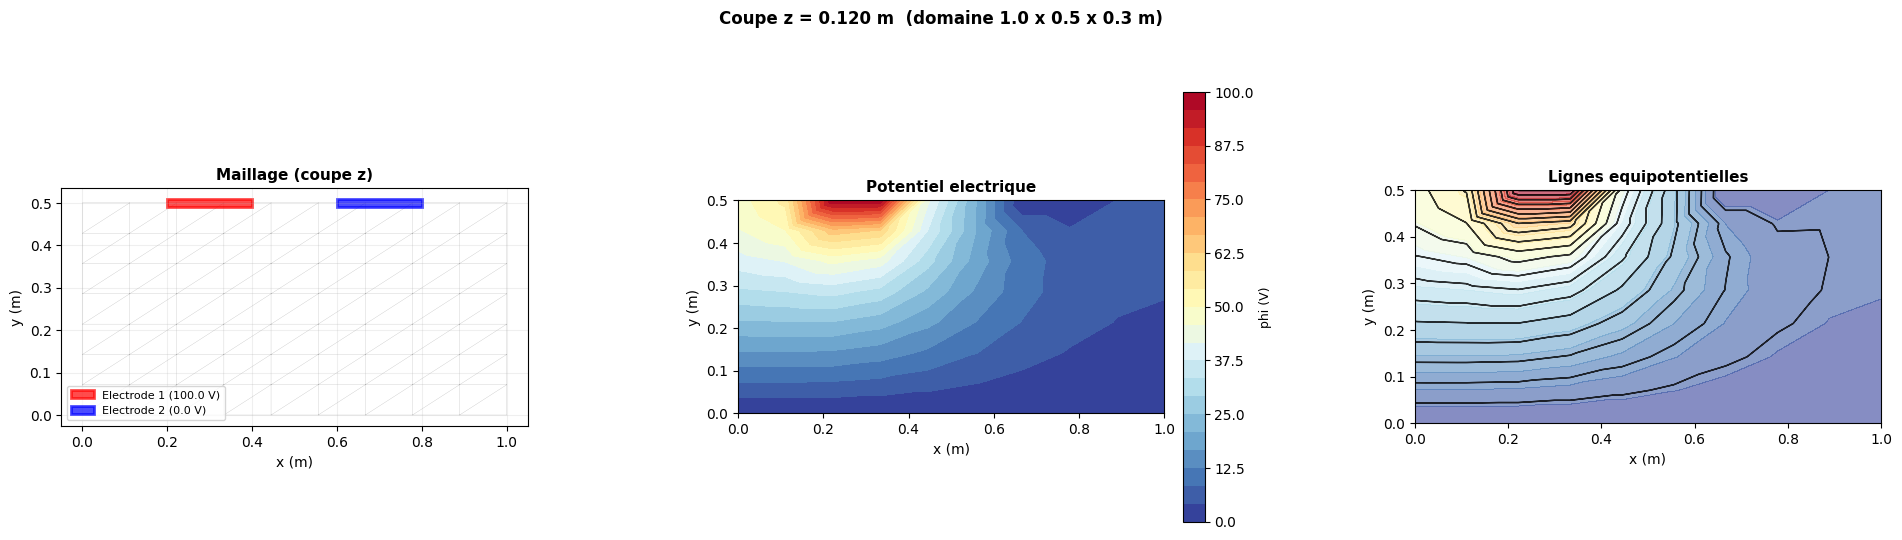

Figure 1 sauvegardee : coplanar_3d_results.png


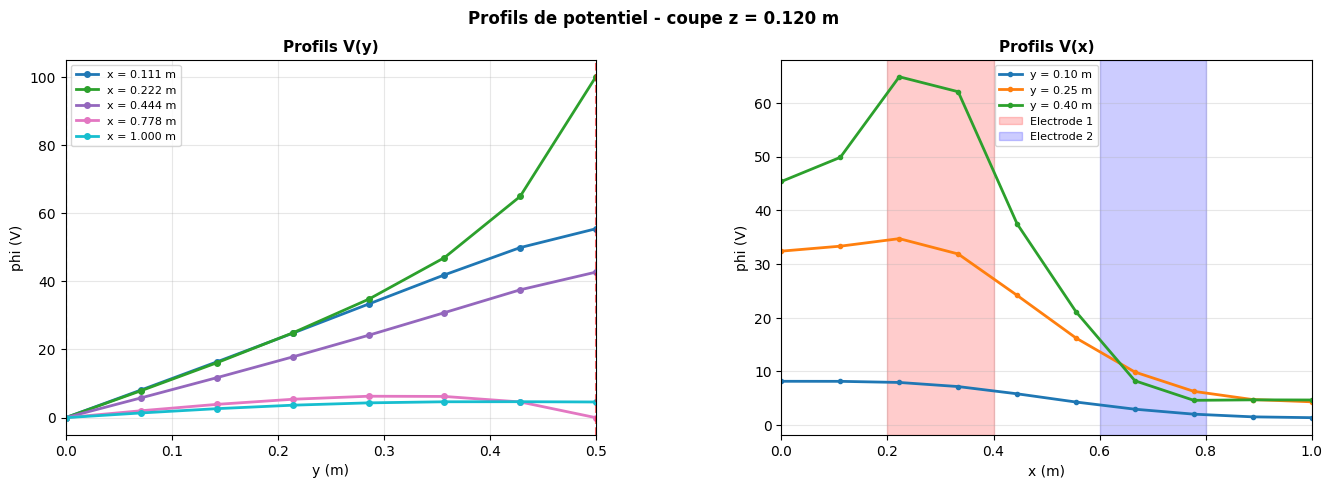

Figure 2 sauvegardee : coplanar_3d_profiles.png
✅ PASS  [T8a - plot_results sans exception]  


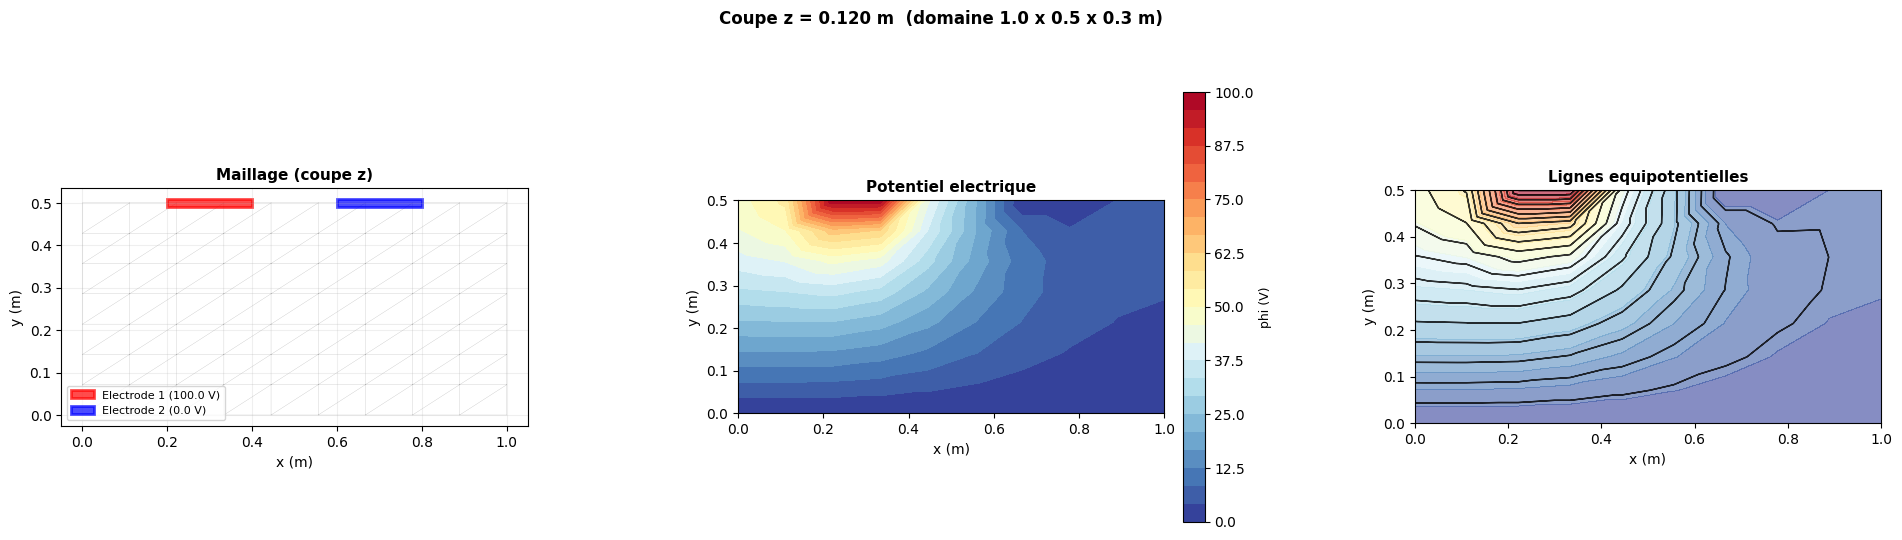

Figure 1 sauvegardee : coplanar_3d_results.png


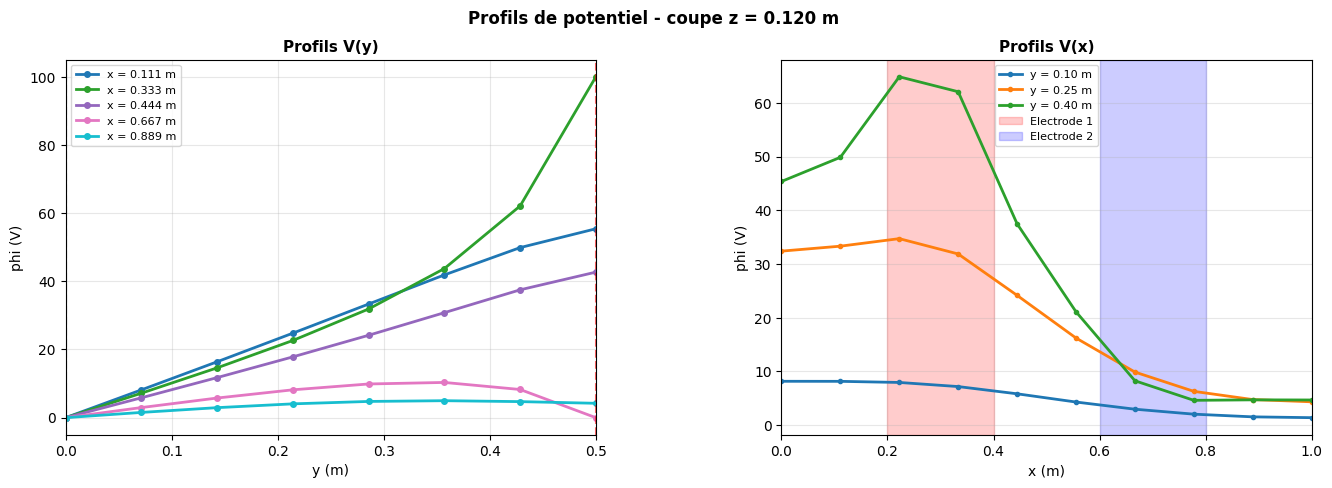

Figure 2 sauvegardee : coplanar_3d_profiles.png
✅ PASS  [T8b - plot_results avec x_cuts et z_cut]  


In [80]:
print('=== T8 : Visualisation plot_results ===')
try:
    fem_t6.plot_results(V_electrode1=100.0, V_electrode2=0.0, V_bottom=0.0)
    check('T8a - plot_results sans exception', True, '')
except Exception as e:
    check('T8a - plot_results sans exception', False, str(e))

# Test avec x_cuts personnalisées
try:
    fem_t6.plot_results(x_cuts=[0.1, 0.3, 0.5, 0.7, 0.9], z_cut=0.1)
    check('T8b - plot_results avec x_cuts et z_cut', True, '')
except Exception as e:
    check('T8b - plot_results avec x_cuts et z_cut', False, str(e))

## Test T8 — Profil V(z)

**Objectif :** vérifier que plot_profile_z s'exécute et que les profils sont cohérents.

=== T9 : Profil V(z) ===
  x=0.33 m, y=0.43 m : V in [51.5358, 62.1061] V  (Delta = 10.5703 V)
  x=0.67 m, y=0.43 m : V in [8.2656, 10.7322] V  (Delta = 2.4666 V)
  x=0.44 m, y=0.07 m : V in [5.8323, 5.8371] V  (Delta = 0.0048 V)


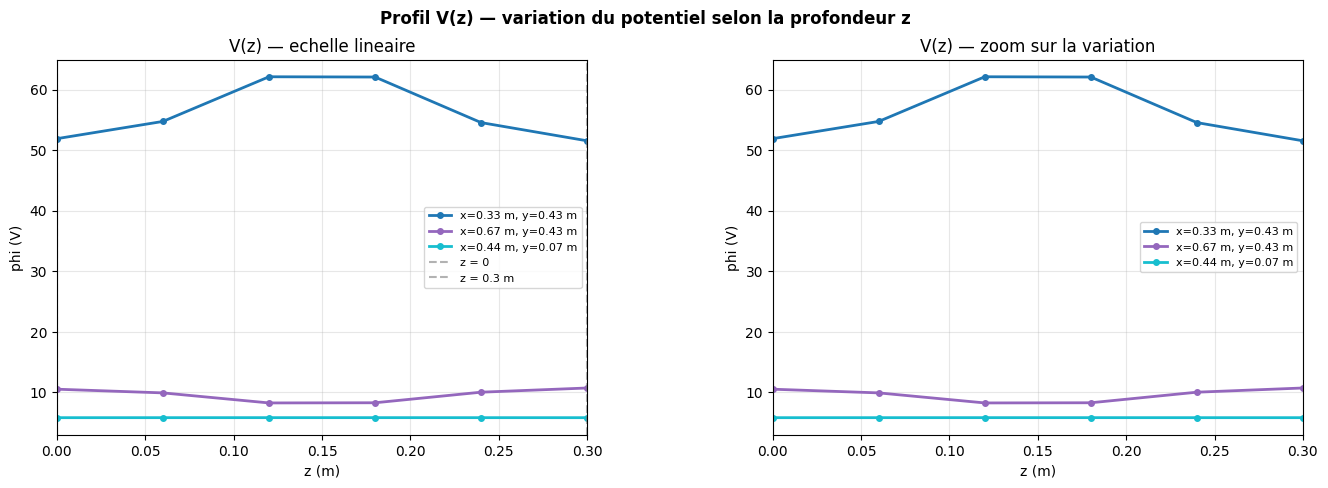

Figure sauvegardee : coplanar_3d_profile_z.png

Interpretation : si V(z) est quasi-constant, le champ est
essentiellement 2D dans le plan (x,y) — la geometrie est
suffisamment large en z. Une variation notable indique un
effet de bord en profondeur.
✅ PASS  [T9a - plot_profile_z sans exception]  
✅ PASS  [T9b - variation V(z) faible au centre]  ΔV(z) = 0.2189 V


In [81]:
print('=== T9 : Profil V(z) ===')
try:
    xy_pts = [(0.3, 0.4), (0.7, 0.4), (0.5, 0.1)]
    fem_t6.plot_profile_z(xy_points=xy_pts)
    check('T9a - plot_profile_z sans exception', True, '')
except Exception as e:
    check('T9a - plot_profile_z sans exception', False, str(e))

# Vérifier que le profil V(z) est quasi-constant quand le domaine est grand en z
# (effet de bord faible)
x_mesh = np.unique(fem_t6.nodes[:,0])
y_mesh = np.unique(fem_t6.nodes[:,1])
tol_x  = fem_t6.length / (2*(fem_t6.nx-1))
tol_y  = fem_t6.height / (2*(fem_t6.ny-1))
xc = x_mesh[np.argmin(np.abs(x_mesh - 0.5))]
yc = y_mesh[np.argmin(np.abs(y_mesh - 0.25))]
mask = (np.abs(fem_t6.nodes[:,0]-xc)<tol_x) & (np.abs(fem_t6.nodes[:,1]-yc)<tol_y)
phi_z = fem_t6.phi[mask]
delta_z = phi_z.max() - phi_z.min()
# La variation selon z doit être faible (< 5% de la plage totale)
check('T9b - variation V(z) faible au centre',
      delta_z < 0.05 * (fem_t6.phi.max() - fem_t6.phi.min()),
      f'ΔV(z) = {delta_z:.4f} V')

## Test T9 — Sauvegarde et rechargement des données

**Objectif :** vérifier que les données sont correctement sauvegardées et rechargées via numpy.

In [82]:
import os
print('=== T10 : Sauvegarde / rechargement ===')
fname = '/tmp/test_coplanar.npz'
np.savez(fname,
    nodes    = fem_t6.nodes,
    elements = fem_t6.elements,
    phi      = fem_t6.phi,
    E_field  = fem_t6.E_field
)

check('T10a - fichier créé', os.path.exists(fname), fname)

data = np.load(fname)
check('T10b - phi rechargé identique',
      np.allclose(data['phi'], fem_t6.phi), '')
check('T10c - nodes rechargés identiques',
      np.allclose(data['nodes'], fem_t6.nodes), '')
check('T10d - E_field rechargé identique',
      np.allclose(data['E_field'], fem_t6.E_field), '')

os.remove(fname)
print('Fichier temporaire supprimé.')

=== T10 : Sauvegarde / rechargement ===
✅ PASS  [T10a - fichier créé]  /tmp/test_coplanar.npz
✅ PASS  [T10b - phi rechargé identique]  
✅ PASS  [T10c - nodes rechargés identiques]  
✅ PASS  [T10d - E_field rechargé identique]  
Fichier temporaire supprimé.


## 10 - Bilan des tests

In [83]:
print('\n' + '='*55)
print('BILAN DES TESTS')
print('='*55)
passed = sum(v for v in results.values())
total  = len(results)
failed = [k for k,v in results.items() if not v]

for name, ok in results.items():
    print(f'  {"✅" if ok else "❌"}  {name}')

print('='*55)
print(f'Résultat : {passed}/{total} tests passés')
if failed:
    print(f'Tests échoués : {", ".join(failed)}')
else:
    print('Tous les tests sont passés avec succès !')
print('='*55)


BILAN DES TESTS
  ✅  T1a - nombre de noeuds
  ✅  T1b - nombre de tetraedres
  ✅  T1c - shape nodes
  ✅  T1d - shape elements
  ✅  T1e - bornes x
  ✅  T1f - bornes y
  ✅  T1g - nœuds fond
  ✅  T2a - electrode1 sur face superieure
  ✅  T2b - electrode2 vide si use_electrode2=False
  ✅  T2c - electrode hors domaine → 0 nœuds
  ✅  T3a - shape 4x4
  ✅  T3b - symétrie
  ✅  T3c - diagonale positive
  ✅  T3d - somme des lignes ≈ 0 (propriété FEM)
  ✅  T3e - tet dégénéré → matrice nulle
  ✅  T4a - shape (n_nodes × n_nodes)
  ✅  T4b - format CSR
  ✅  T4c - symétrie
  ✅  T6a - phi défini
  ✅  T6b - electrode1 ≈ 100 V
  ✅  T6c - electrode2 ≈ 0 V
  ✅  T6d - fond ≈ 0 V
  ✅  T6e - potentiel borné [0, 100]
  ✅  T6f - pas de NaN
  ✅  T7a - shape (n_elements, 3)
  ✅  T7b - pas de NaN
  ✅  T7c - E stocké dans fem.E_field
  ✅  T7d - champ uniforme Ey ≈ -1 V/m
  ✅  T8a - plot_results sans exception
  ✅  T8b - plot_results avec x_cuts et z_cut
  ✅  T9a - plot_profile_z sans exception
  ✅  T9b - variation V